## 8.2 대화 맥락을 이해하는 에이전트

### 8.2.1 [실습] 랭그래프에서 단기 메모리 사용하기

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph
from typing import Annotated

from operator import add

graph_builder = StateGraph(Annotated[int, add]) # [ 1 ]

graph_builder.add_node("get_one", lambda x: 1) # [ 2 ]
graph_builder.set_entry_point("get_one")
graph_builder.set_finish_point("get_one")

graph = graph_builder.compile(checkpointer=InMemorySaver()) # [ 3 ]

result1 = graph.invoke(0, {"configurable": {"thread_id": "user1"}}) # [ 4 ]
print(f"첫 번째 호출 결과: {result1}\n")

result2 = graph.invoke(0, {"configurable": {"thread_id": "user1"}})
print(f"두 번째 호출 결과: {result2}\n")

result3 = graph.invoke(0, {"configurable": {"thread_id": "user1"}})
print(f"세 번째 호출 결과: {result3}")

첫 번째 호출 결과: 1

두 번째 호출 결과: 2

세 번째 호출 결과: 3


## 8.2.2 [실습] 챗봇에 단기 메모리 적용하기

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph
from langchain_openai import ChatOpenAI

from dotenv import load_dotenv

load_dotenv()

class State(TypedDict): # [ 1 ]
    messages: Annotated[list, add_messages]


llm = ChatOpenAI(model="gpt-4o") # [ 2 ]

def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

graph_builder = StateGraph(State) # [ 3 ]
graph_builder.add_node("chatbot", chatbot)
graph_builder.set_entry_point("chatbot")
graph_builder.set_finish_point("chatbot")

checkpointer = InMemorySaver()
graph = graph_builder.compile(checkpointer=checkpointer)


graph.invoke(
    {"messages": [{"role": "user", "content": "안녕하세요! 제 이름은 공원나연입니다."}]},
    {"configurable": {"thread_id": "1"}},
)

{'messages': [HumanMessage(content='안녕하세요! 제 이름은 공원나연입니다.', additional_kwargs={}, response_metadata={}, id='f607e1c1-044f-44cb-bf6d-d99efef2cb3c'),
  AIMessage(content='안녕하세요, 나연님! 만나서 반갑습니다. 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 19, 'total_tokens': 39, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_65564d8ba5', 'id': 'chatcmpl-CVvP6WFGcerCCzLU1H7Y5kLcg6wAb', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--9a1ecbd1-f340-477b-b8d9-fb9b9e81ff31-0', usage_metadata={'input_tokens': 19, 'output_tokens': 20, 'total_tokens': 39, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoni

In [4]:
graph.invoke(
    {"messages": [{"role": "user", "content": "제 이름이 뭐라고요?"}]},
    {"configurable": {"thread_id": "1"}},
)

{'messages': [HumanMessage(content='안녕하세요! 제 이름은 공원나연입니다.', additional_kwargs={}, response_metadata={}, id='f607e1c1-044f-44cb-bf6d-d99efef2cb3c'),
  AIMessage(content='안녕하세요, 나연님! 만나서 반갑습니다. 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 19, 'total_tokens': 39, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_65564d8ba5', 'id': 'chatcmpl-CVvP6WFGcerCCzLU1H7Y5kLcg6wAb', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--9a1ecbd1-f340-477b-b8d9-fb9b9e81ff31-0', usage_metadata={'input_tokens': 19, 'output_tokens': 20, 'total_tokens': 39, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoni

## 8.3 단기 메모리를 관리하는 방법

### 8.3.1 [실습] 메시지 트리밍 활용하기


In [5]:
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
from langchain_core.messages.utils import (
    trim_messages,
    count_tokens_approximately
)
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

model = init_chat_model("openai:gpt-4o")

def call_model(state: MessagesState):
    messages = trim_messages( # [ 1 ]
        state["messages"],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=128, #1024
        start_on="human",
        end_on=("human", "tool"),
    )
    print(f"Trimmed messages: {messages}")
    response = model.invoke(messages)
    return {"messages": [response]}


graph_builder = StateGraph(MessagesState) # [ 2 ]
graph_builder.add_node(call_model)
graph_builder.add_edge(START, "call_model")

checkpointer = InMemorySaver() # [ 3 ]
graph = graph_builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "1"}}
graph.invoke({"messages": "안녕하세요, 저는 AI를 공부하는 학생입니다."}, config)
graph.invoke({"messages": "앞으로 AI를 사용할 때 주의해야 할 점을 조사하고 있어요."}, config)
graph.invoke({"messages": "또 어떤 주제에 대해 공부하면 좋을까요?"}, config)
final_response = graph.invoke({"messages": "제가 뭘 공부하고 있나요?"}, config)

final_response["messages"][-1].pretty_print()

Trimmed messages: [HumanMessage(content='안녕하세요, 저는 AI를 공부하는 학생입니다.', additional_kwargs={}, response_metadata={}, id='2470cfc6-5ecf-405b-abb7-cbc6f9fb94e8')]
Trimmed messages: [HumanMessage(content='안녕하세요, 저는 AI를 공부하는 학생입니다.', additional_kwargs={}, response_metadata={}, id='2470cfc6-5ecf-405b-abb7-cbc6f9fb94e8'), AIMessage(content='안녕하세요! AI를 공부하고 계신다니 멋지네요. 어떤 특정 분야나 주제에 관심이 있으신가요? 궁금한 점이나 도움이 필요하면 언제든지 말씀해 주세요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 18, 'total_tokens': 63, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_65564d8ba5', 'id': 'chatcmpl-CVvPBoqu62qdunzRK3FCsTBdE3aS6', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--990e1

### 더 알아보기 | 단일 혹은 전체 메시지 삭제하기

In [7]:
from langchain.messages import RemoveMessage

def delete_messages(state):
    messages = state["messages"]
    if len(messages) > 2:
        return {"messages": [RemoveMessage(id=m.id) for m in messages[:2]]}

In [8]:
from langgraph.graph.message import REMOVE_ALL_MESSAGES

def delete_messages(state):
    return {"messages": [RemoveMessage(id=REMOVE_ALL_MESSAGES)]}

### 8.3.2 [실습] 메시지 요약 활용하기

In [ ]:
from langchain_core.messages import HumanMessage, RemoveMessage
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, MessagesState, END
from langgraph.checkpoint.memory import InMemorySaver

class State(MessagesState): # [ 1 ]
    summary: str

model = init_chat_model("openai:gpt-4o")

def summarize_conversation(state: State): # [ 2 ]
    summary = state.get("summary", "")

    if summary:
        summary_message = (
            f"지금까지 대화 요약: {summary}\n\n"
            "위의 새로운 메시지를 고려하여 요약을 확장해주세요:"
        )
    else:
        summary_message = "위 대화 내용을 요약해주세요:"

    messages = state["messages"] + [HumanMessage(content=summary_message)] # [ 3 ]
    response = model.invoke(messages)

    # 최근 메시지 2개만 남기기
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]] # [ 4 ]
    return {"summary": response.content, "messages": delete_messages}

In [ ]:
def call_model(state: State): # [ 1 ]
    summary = state.get("summary", "")
    if summary:
        system_message = f"이전 대화 요약: {summary}"
        messages = [{"role": "system", "content": system_message}] + state["messages"]
    else:
        messages = state["messages"]

    response = model.invoke(messages)
    return {"messages": [response]}

def should_continue(state: State): # [ 2 ]
    messages = state["messages"]
    if len(messages) > 6:
        return "summarize_conversation"
    return "model"

graph_builder = StateGraph(State) # [ 3 ]
graph_builder.add_node("call_model", call_model)
graph_builder.add_node("summarize_conversation", summarize_conversation)

graph_builder.add_edge("summarize_conversation", "call_model")
graph_builder.add_conditional_edges(
    START,
    should_continue,
    {
        "model": "call_model",
        "summarize_conversation": "summarize_conversation"
    }
)
graph_builder.add_edge("call_model", END)

checkpointer = InMemorySaver() # [ 4 ]
graph = graph_builder.compile(checkpointer=checkpointer)

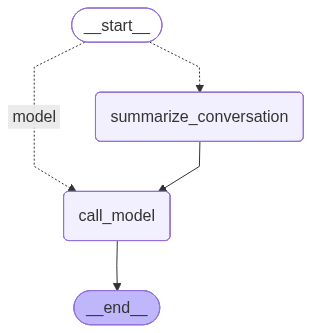

In [24]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [ ]:
config = {"configurable": {"thread_id": "1"}}
graph.invoke({"messages": "안녕하세요, 저는 AI를 공부하는 학생입니다."}, config)
graph.invoke({"messages": "앞으로 AI를 사용할 때 주의해야 할 점을 조사하고 있어요."}, config)
graph.invoke({"messages": "또 어떤 주제에 대해 공부하면 좋을까요?"}, config)
final_response = graph.invoke({"messages": "제가 뭘 공부하고 있나요?"}, config)

if final_response.get('summary'):
    print(f"요약: {final_response['summary']}\n")
final_response["messages"][-1].pretty_print()


요약: 당신은 AI를 공부하는 학생이며, AI를 사용할 때 주의해야 할 점을 조사하고 있습니다. 제가 AI 사용 시 주의해야 할 점과 관련된 여러 가지 중요한 요소를 설명드렸습니다. 또한, AI와 관련된 다른 공부 주제로 기계 학습, 딥러닝, 자연어 처리, 컴퓨터 비전, 강화 학습, AI 윤리 및 정책, 데이터 과학, AI 비즈니스 전략, 설명 가능한 AI, 그리고 로보틱스 등을 제안드렸습니다.

================================== Ai Message ==================================

당신은 AI(인공지능)를 공부하고 계신다고 하셨습니다. AI와 관련된 다양한 주제에 대해 관심을 가지고 계시며, AI 사용 시 주의해야 할 점에 대해서도 조사하고 있는 것으로 알고 있습니다. 특별히 깊게 탐구하고 싶은 AI의 특정 분야가 있다면, 그에 맞춘 추가적인 정보를 드릴 수 있습니다.


### 더 알아보기 | 체크포인트 관리하기

In [29]:
graph.get_state({"configurable": {"thread_id": "1"}})

StateSnapshot(values={'messages': [AIMessage(content='AI를 공부하면서 탐구할 가치가 있는 주제들은 매우 다양합니다. 다음은 AI와 관련하여 깊이 있게 공부할 만한 몇 가지 주제입니다:\n\n1. **머신러닝 및 딥러닝**: 머신러닝의 기본 개념부터 심화 기법들까지, 다양한 알고리즘과 모델을 학습하면 AI의 기본 원리를 이해하는 데 큰 도움이 됩니다. 특히 딥러닝의 경우, 신경망 구조, CNN, RNN, Transformer 등 다양한 아키텍처를 탐구할 수 있습니다.\n\n2. **자연어 처리(NLP)**: 컴퓨터가 인간의 언어를 이해하고 생성할 수 있도록 하는 기술로, 언어 모델, 텍스트 분석, 감정 분석, 기계 번역 등을 포함합니다.\n\n3. **컴퓨터 비전**: 이미지와 영상 데이터를 처리하는 기술로, 객체 인식, 이미지 분류, 얼굴 인식, 자율 주행 등의 주제를 다룹니다.\n\n4. **강화 학습**: 에이전트가 환경과 상호작용하며 보상을 최대화하기 위한 의사 결정을 연구하는 분야로, 게임 AI나 로봇 제어 등 다양한 응용이 있습니다.\n\n5. **AI 윤리 및 사회적 영향**: AI의 발전이 사회에 미치는 영향을 연구하고, 윤리적으로 올바른 AI 시스템을 개발하기 위한 방안을 모색합니다.\n\n6. **데이터 사이언스와 데이터 전처리**: AI 모델을 학습하기 위한 데이터를 수집, 정제, 분석하는 기술을 공부합니다. 데이터의 질이 AI 모델의 성능에 큰 영향을 미치기 때문에 매우 중요한 주제입니다.\n\n7. **AI 플랫폼과 프레임워크**: TensorFlow, PyTorch 등 AI 모델을 개발하고 배포할 때 사용하는 플랫폼에 대해 학습하세요. 이러한 도구들은 AI 연구와 개발을 효율적으로 할 수 있게 도와줍니다.\n\n8. **신경망 해석 및 설명 가능 인공지능(XAI)**: AI 시스템의 복잡한 의사 결정 과정을 이해하고 설명하는 기술로, 투명성과 신뢰성을 높이는 데 중요합니다.\n\n9. **양자

In [30]:
list(graph.get_state_history({"configurable": {"thread_id": "1"}}))

[StateSnapshot(values={'messages': [AIMessage(content='AI를 공부하면서 탐구할 가치가 있는 주제들은 매우 다양합니다. 다음은 AI와 관련하여 깊이 있게 공부할 만한 몇 가지 주제입니다:\n\n1. **머신러닝 및 딥러닝**: 머신러닝의 기본 개념부터 심화 기법들까지, 다양한 알고리즘과 모델을 학습하면 AI의 기본 원리를 이해하는 데 큰 도움이 됩니다. 특히 딥러닝의 경우, 신경망 구조, CNN, RNN, Transformer 등 다양한 아키텍처를 탐구할 수 있습니다.\n\n2. **자연어 처리(NLP)**: 컴퓨터가 인간의 언어를 이해하고 생성할 수 있도록 하는 기술로, 언어 모델, 텍스트 분석, 감정 분석, 기계 번역 등을 포함합니다.\n\n3. **컴퓨터 비전**: 이미지와 영상 데이터를 처리하는 기술로, 객체 인식, 이미지 분류, 얼굴 인식, 자율 주행 등의 주제를 다룹니다.\n\n4. **강화 학습**: 에이전트가 환경과 상호작용하며 보상을 최대화하기 위한 의사 결정을 연구하는 분야로, 게임 AI나 로봇 제어 등 다양한 응용이 있습니다.\n\n5. **AI 윤리 및 사회적 영향**: AI의 발전이 사회에 미치는 영향을 연구하고, 윤리적으로 올바른 AI 시스템을 개발하기 위한 방안을 모색합니다.\n\n6. **데이터 사이언스와 데이터 전처리**: AI 모델을 학습하기 위한 데이터를 수집, 정제, 분석하는 기술을 공부합니다. 데이터의 질이 AI 모델의 성능에 큰 영향을 미치기 때문에 매우 중요한 주제입니다.\n\n7. **AI 플랫폼과 프레임워크**: TensorFlow, PyTorch 등 AI 모델을 개발하고 배포할 때 사용하는 플랫폼에 대해 학습하세요. 이러한 도구들은 AI 연구와 개발을 효율적으로 할 수 있게 도와줍니다.\n\n8. **신경망 해석 및 설명 가능 인공지능(XAI)**: AI 시스템의 복잡한 의사 결정 과정을 이해하고 설명하는 기술로, 투명성과 신뢰성을 높이는 데 중요합니다.\n\n9. **양

In [32]:
thread_id = "1"
checkpointer.delete_thread(thread_id)

In [33]:
graph.get_state({"configurable": {"thread_id": "1"}})

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '1'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())